In [28]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import missingno as msno

In [4]:
# divorces dataset
df = pd.read_csv("dataset/divorces_2000-2015_translated.csv")
df.columns

Index(['Divorce_date', 'Type_of_divorce', 'Nationality_partner_man',
       'DOB_partner_man', 'Place_of_birth_partner_man',
       'Birth_municipality_of_partner_man', 'Birth_federal_partner_man',
       'Birth_country_partner_man', 'Age_partner_man',
       'Residence_municipality_partner_man', 'Residence_federal_partner_man',
       'Residence_country_partner_man', 'Monthly_income_partner_man_peso',
       'Occupation_partner_man', 'Place_of_residence_partner_man',
       'Nationality_partner_woman', 'DOB_partner_woman',
       'DOB_registration_date_partner_woman', 'Place_of_birth_partner_woman',
       'Birth_municipality_of_partner_woman', 'Birth_federal_partner_woman',
       'Birth_country_partner_woman', 'Age_partner_woman',
       'Place_of_residence_partner_woman',
       'Residence_municipality_partner_woman',
       'Residence_federal_partner_woman', 'Residence_country_partner_woman',
       'Occupation_partner_woman', 'Monthly_income_partner_woman_peso',
       'Date_of_m

Important columns

1. Divorce_date
2. Type_of_divorce
3. DOB_partner_man
4. DOB_partner_woman
5. Marriage Duration
6. Marriage Duration Months


In [6]:
divorce = df[["Divorce_date", "DOB_partner_man", "DOB_partner_woman", "Type_of_divorce", "Marriage_duration", "Marriage_duration_months"]]
divorce_subset = divorce.dropna()
divorce_subset

,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months
8,1/2/08,2/12/76,3/1/80,Voluntario,1.0,7.0
9,1/2/08,17/11/76,13/3/77,Voluntario,7.0,11.0
13,1/2/11,31/1/73,5/11/70,Necesario,12.0,3.0
20,1/3/05,3/10/71,30/3/72,Necesario,11.0,8.0
28,1/3/11,9/3/84,26/3/88,Necesario,3.0,1.0
...,...,...,...,...,...,...
4906,31/10/02,18/8/51,1/6/66,Voluntario,6.0,3.0
4907,31/10/02,27/10/51,26/7/67,Voluntario,18.0,10.0
4908,31/10/03,11/8/76,6/11/74,Voluntario,3.0,8.0
4909,31/10/03,15/12/66,15/7/74,Voluntario,4.0,10.0


<Axes: >

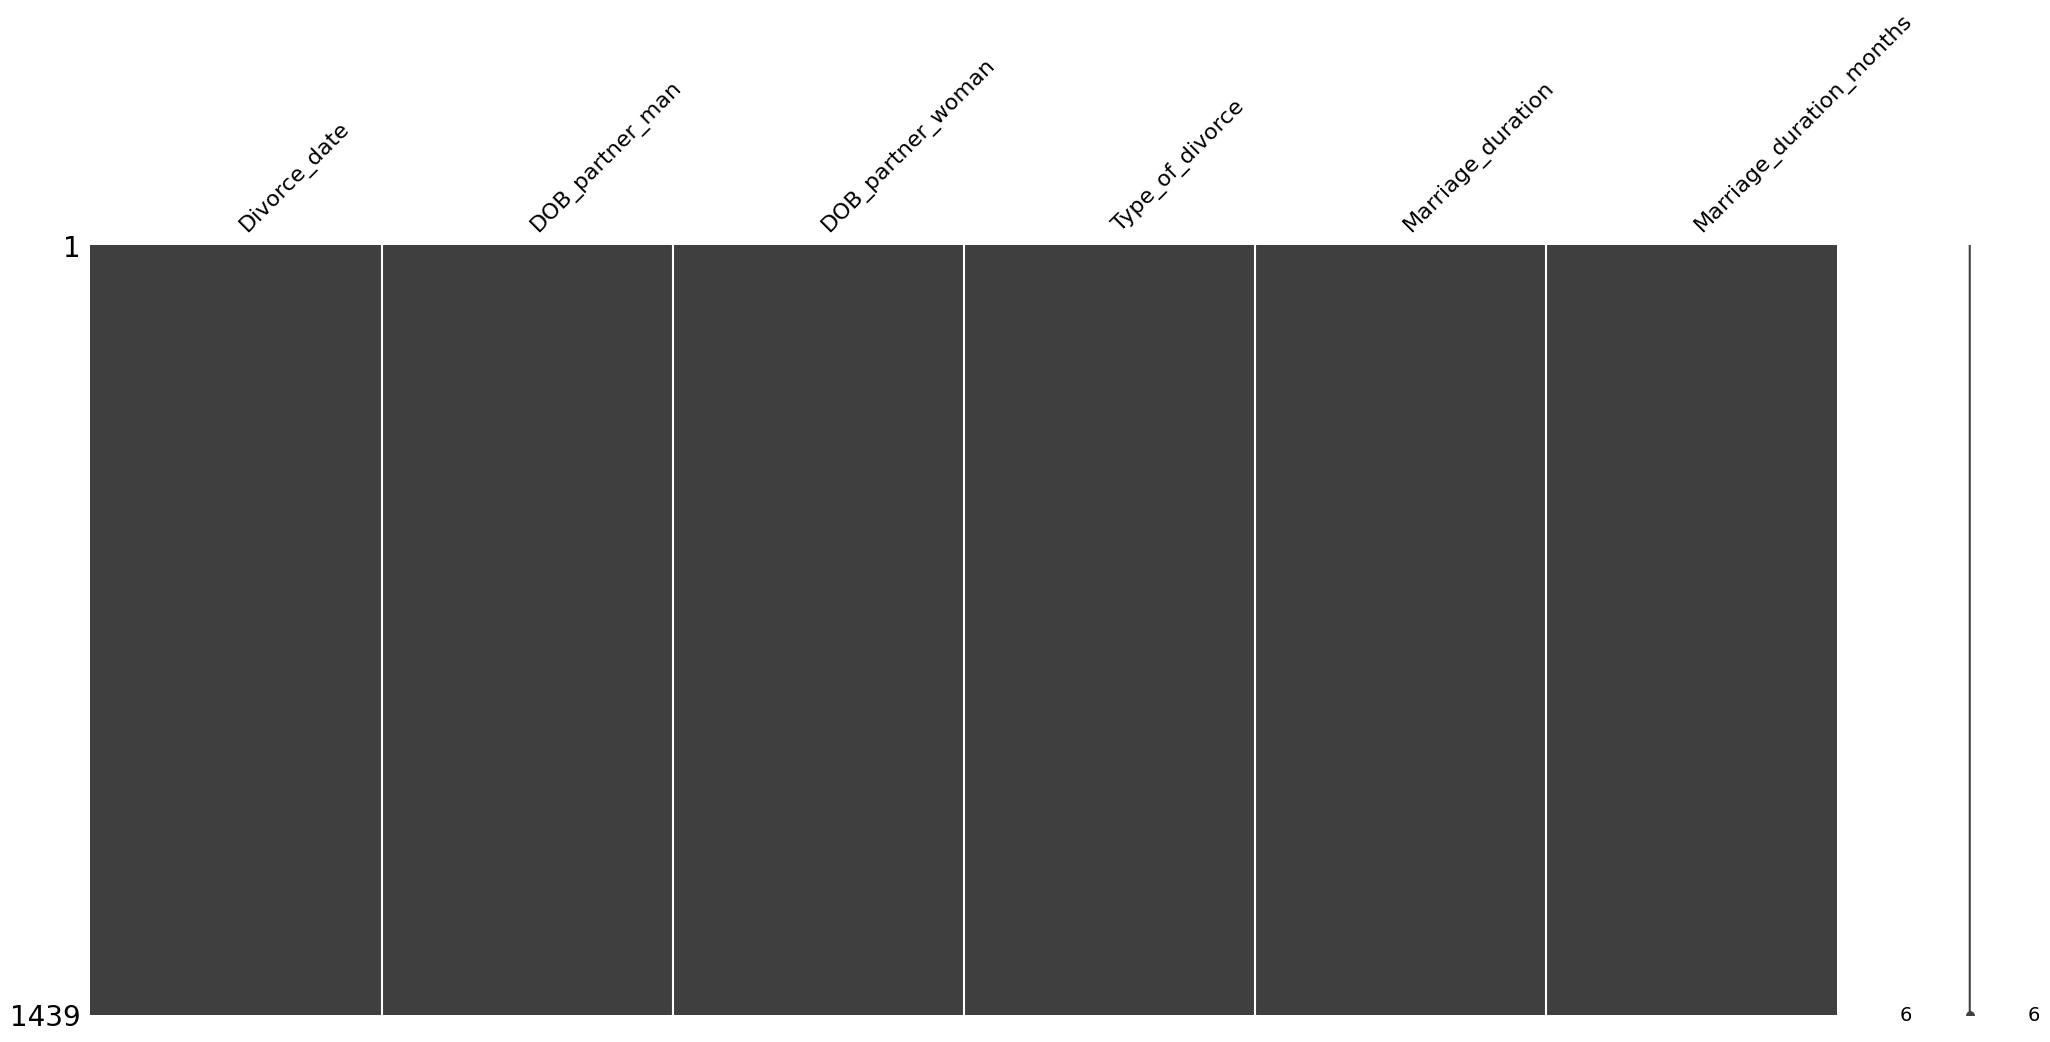

In [7]:
msno.matrix(divorce_subset)

In [24]:
divorce_subset["DOB_partner_man"] = pd.to_datetime(divorce_subset["DOB_partner_man"], format="%d/%m/%y")
divorce_subset["DOB_partner_woman"] = pd.to_datetime(divorce_subset["DOB_partner_woman"], format="%d/%m/%y")

In [9]:
def get_zodiac_sign(date):
    day = date.day
    month = date.month

    if (month == 3 and day >= 21) or (month == 4 and day <= 19):
        return "Aries"
    elif (month == 4 and day >= 20) or (month == 5 and day <= 20):
        return "Taurus"
    elif (month == 5 and day >= 21) or (month == 6 and day <= 20):
        return "Gemini"
    elif (month == 6 and day >= 21) or (month == 7 and day <= 22):
        return "Cancer"
    elif (month == 7 and day >= 23) or (month == 8 and day <= 22):
        return "Leo"
    elif (month == 8 and day >= 23) or (month == 9 and day <= 22):
        return "Virgo"
    elif (month == 9 and day >= 23) or (month == 10 and day <= 22):
        return "Libra"
    elif (month == 10 and day >= 23) or (month == 11 and day <= 21):
        return "Scorpio"
    elif (month == 11 and day >= 22) or (month == 12 and day <= 21):
        return "Sagittarius"
    elif (month == 12 and day >= 22) or (month == 1 and day <= 19):
        return "Capricorn"
    elif (month == 1 and day >= 20) or (month == 2 and day <= 18):
        return "Aquarius"
    else:
        return "Pisces"

In [23]:
divorce_subset["zodiac_sign_man"] = divorce_subset["DOB_partner_man"].apply(get_zodiac_sign)
divorce_subset

,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign,zodiac_sign_man
8,1/2/08,1976-12-02,3/1/80,Volunteer,1.0,7.0,Sagittarius,Sagittarius
9,1/2/08,1976-11-17,13/3/77,Volunteer,7.0,11.0,Scorpio,Scorpio
13,1/2/11,1973-01-31,5/11/70,Necessary,12.0,3.0,Aquarius,Aquarius
20,1/3/05,1971-10-03,30/3/72,Necessary,11.0,8.0,Libra,Libra
28,1/3/11,1984-03-09,26/3/88,Necessary,3.0,1.0,Pisces,Pisces
...,...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,1/6/66,Volunteer,6.0,3.0,Leo,Leo
4907,31/10/02,2051-10-27,26/7/67,Volunteer,18.0,10.0,Scorpio,Scorpio
4908,31/10/03,1976-08-11,6/11/74,Volunteer,3.0,8.0,Leo,Leo
4909,31/10/03,2066-12-15,15/7/74,Volunteer,4.0,10.0,Sagittarius,Sagittarius


In [25]:
divorce_subset["zodiac_sign_woman"] = divorce_subset["DOB_partner_woman"].apply(get_zodiac_sign)
divorce_subset

,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign,zodiac_sign_man,zodiac_sign_woman
8,1/2/08,1976-12-02,1980-01-03,Volunteer,1.0,7.0,Sagittarius,Sagittarius,Capricorn
9,1/2/08,1976-11-17,1977-03-13,Volunteer,7.0,11.0,Scorpio,Scorpio,Pisces
13,1/2/11,1973-01-31,1970-11-05,Necessary,12.0,3.0,Aquarius,Aquarius,Scorpio
20,1/3/05,1971-10-03,1972-03-30,Necessary,11.0,8.0,Libra,Libra,Aries
28,1/3/11,1984-03-09,1988-03-26,Necessary,3.0,1.0,Pisces,Pisces,Aries
...,...,...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,2066-06-01,Volunteer,6.0,3.0,Leo,Leo,Gemini
4907,31/10/02,2051-10-27,2067-07-26,Volunteer,18.0,10.0,Scorpio,Scorpio,Leo
4908,31/10/03,1976-08-11,1974-11-06,Volunteer,3.0,8.0,Leo,Leo,Scorpio
4909,31/10/03,2066-12-15,1974-07-15,Volunteer,4.0,10.0,Sagittarius,Sagittarius,Cancer


In [17]:
divorce_subset["Type_of_divorce"].value_counts()

Type_of_divorce
Voluntario    1232
Necesario      207
Name: count, dtype: int64

In [20]:
# Translate divorce types from Spanish to English 
divorce_subset["Type_of_divorce"] = divorce_subset["Type_of_divorce"].replace({
    "Voluntario": "Volunteer",
    "Necesario": "Necessary"
})

divorce_subset["Type_of_divorce"].value_counts()
divorce_subset

,Divorce_date,DOB_partner_man,DOB_partner_woman,Type_of_divorce,Marriage_duration,Marriage_duration_months,zodiac_sign
8,1/2/08,1976-12-02,3/1/80,Volunteer,1.0,7.0,Sagittarius
9,1/2/08,1976-11-17,13/3/77,Volunteer,7.0,11.0,Scorpio
13,1/2/11,1973-01-31,5/11/70,Necessary,12.0,3.0,Aquarius
20,1/3/05,1971-10-03,30/3/72,Necessary,11.0,8.0,Libra
28,1/3/11,1984-03-09,26/3/88,Necessary,3.0,1.0,Pisces
...,...,...,...,...,...,...,...
4906,31/10/02,2051-08-18,1/6/66,Volunteer,6.0,3.0,Leo
4907,31/10/02,2051-10-27,26/7/67,Volunteer,18.0,10.0,Scorpio
4908,31/10/03,1976-08-11,6/11/74,Volunteer,3.0,8.0,Leo
4909,31/10/03,2066-12-15,15/7/74,Volunteer,4.0,10.0,Sagittarius
